# Proyecto Final DL — Fase 1

Este notebook cubre únicamente:
1. Selección y documentación del dataset.
2. EDA completo.
3. Definición de modelo MLP base.
4. Métricas de evaluación.

> En esta fase **no** se entrena ni se hace clasificación final.

## Dataset seleccionado
- Fuente: Kaggle
- Nombre: **Skin Diseases Cancer Comprehensive Dataset**
- Croissant JSON-LD:
  https://www.kaggle.com/datasets/anieetorudofia/skin-diseases-cancer-comprehensive-dataset/croissant/download

Este dataset es principalmente de **imágenes**, por lo que el análisis se hará por archivos/etiquetas de carpetas y metadatos de imagen (no por tabla tabular).

In [1]:
import json
from pathlib import Path
import mlcroissant as mlc
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

In [2]:
DATASET_URL = (
    "https://www.kaggle.com/datasets/anieetorudofia/"
    "skin-diseases-cancer-comprehensive-dataset/croissant/download"
)

KAGGLE_DATASET_SLUG = "anieetorudofia/skin-diseases-cancer-comprehensive-dataset"

croissant_dataset = mlc.Dataset(DATASET_URL)
record_sets = croissant_dataset.metadata.record_sets

print("Record sets detectados:", len(record_sets))
if len(record_sets) > 0:
    for i, rs in enumerate(record_sets, start=1):
        print(f"{i}. name={getattr(rs, 'name', 'N/A')} | uuid={getattr(rs, 'uuid', 'N/A')}")
else:
    print("Croissant no expone records tabulares para este dataset (esperable si solo contiene imágenes).")

dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET_SLUG))
print("Ruta local del dataset:", dataset_path)

  -  [Metadata(Skin Diseases + Cancer Comprehensive Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


Record sets detectados: 0
Croissant no expone records tabulares para este dataset (esperable si solo contiene imágenes).
Ruta local del dataset: C:\Users\arani\.cache\kagglehub\datasets\anieetorudofia\skin-diseases-cancer-comprehensive-dataset\versions\7


In [3]:
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

image_files = [
    p for p in dataset_path.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_ext
]

images_df = pd.DataFrame({
    "file_path": [str(p) for p in image_files],
    "label": [p.parent.name for p in image_files],
    "ext": [p.suffix.lower() for p in image_files],
    "file_size_bytes": [p.stat().st_size for p in image_files],
})

print("Total de imágenes encontradas:", len(images_df))
print("Shape:", images_df.shape)
images_df.head()

Total de imágenes encontradas: 13034
Shape: (13034, 4)


,file_path,label,ext,file_size_bytes
0,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,85985
1,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,95923
2,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,99551
3,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,14141
4,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,12772


In [4]:
def read_image_metadata(path_str: str):
    try:
        with Image.open(path_str) as img:
            width, height = img.size
            mode = img.mode
        channels_map = {"L": 1, "RGB": 3, "RGBA": 4}
        channels = channels_map.get(mode, np.nan)
        return width, height, mode, channels, None
    except Exception as err:
        return np.nan, np.nan, None, np.nan, str(err)

meta = images_df["file_path"].apply(read_image_metadata)
images_df[["width", "height", "mode", "channels", "read_error"]] = pd.DataFrame(meta.tolist(), index=images_df.index)
images_df["aspect_ratio"] = images_df["width"] / images_df["height"]
images_df["file_size_kb"] = images_df["file_size_bytes"] / 1024

images_df.head()

,file_path,label,ext,file_size_bytes,width,height,mode,channels,read_error,aspect_ratio,file_size_kb
0,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,85985,720,472,RGB,3.0,None,1.525424,83.969727
1,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,95923,720,472,RGB,3.0,None,1.525424,93.674805
2,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,99551,720,472,RGB,3.0,None,1.525424,97.217773
3,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,14141,294,222,RGB,3.0,None,1.324324,13.809570
4,C:\Users\arani\.cache\kagglehub\datasets\aniee...,Acne,.jpeg,12772,294,222,RGB,3.0,None,1.324324,12.472656


In [5]:
df = images_df.copy()

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("Duplicados por ruta:", df.duplicated(subset=["file_path"]).sum())
print("Errores de lectura:", df["read_error"].notna().sum())

display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing").sort_values("missing", ascending=False))

Filas: 13034
Columnas: 11
Duplicados por ruta: 0
Errores de lectura: 0


,dtype
file_path,object
label,object
ext,object
file_size_bytes,int64
width,int64
height,int64
mode,object
channels,float64
read_error,object
aspect_ratio,float64


,missing
read_error,13034
channels,1
file_path,0
label,0
ext,0
file_size_bytes,0
width,0
height,0
mode,0
aspect_ratio,0


In [6]:
numeric_cols = ["file_size_kb", "width", "height", "channels", "aspect_ratio"]
categorical_cols = ["label", "ext", "mode"]

print("Columnas numéricas:", numeric_cols)
print("Columnas categóricas:", categorical_cols)

display(df[numeric_cols].describe().T)

print("\nTop 20 clases por cantidad:")
display(df["label"].value_counts().head(20).to_frame("count"))

print("\nDistribución de extensiones:")
display(df["ext"].value_counts().to_frame("count"))

print("\nDistribución de modo de color:")
display(df["mode"].value_counts(dropna=False).to_frame("count"))

Columnas numéricas: ['file_size_kb', 'width', 'height', 'channels', 'aspect_ratio']
Columnas categóricas: ['label', 'ext', 'mode']


,count,mean,std,min,25%,50%,75%,max
file_size_kb,13034.0,97.332892,356.643912,1.124023,52.724121,83.367188,104.388916,20430.052734
width,13034.0,609.975372,309.240926,100.000000,477.000000,720.000000,720.000000,8688.000000
height,13034.0,491.488568,239.961862,73.000000,450.000000,473.000000,512.000000,5792.000000
channels,13033.0,3.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000
aspect_ratio,13034.0,1.303401,0.339302,0.357333,1.323077,1.484536,1.525424,3.610169



Top 20 clases por cantidad:


,count
label,
Benign_tumors,1094
Eczema,1016
Tinea,926
Psoriasis,835
Actinic_Keratosis,750
Vitiligo,714
Acne,600
Warts,589
Lichen,568



Distribución de extensiones:


,count
ext,
.jpeg,11590
.jpg,1443
.png,1



Distribución de modo de color:


,count
mode,
RGB,13033
P,1


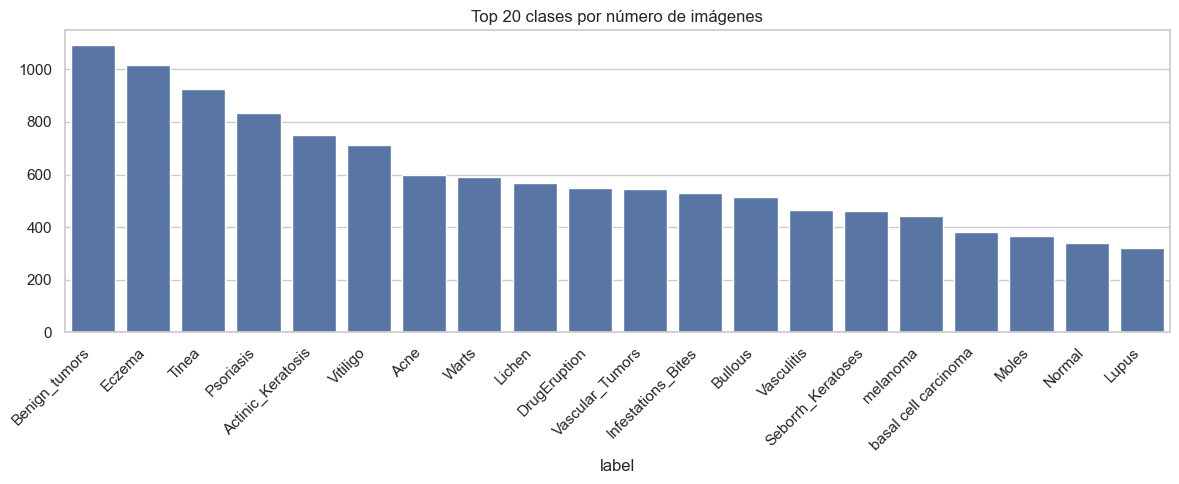

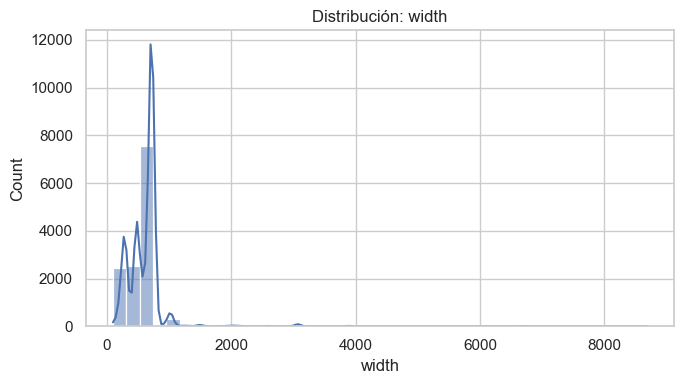

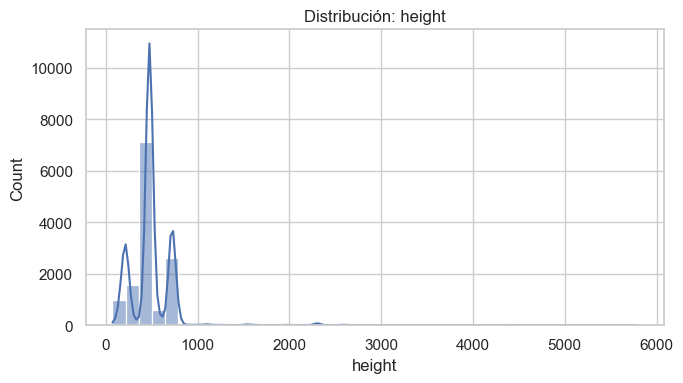

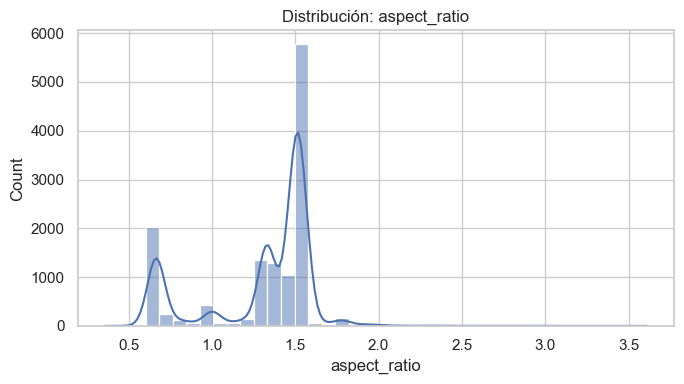

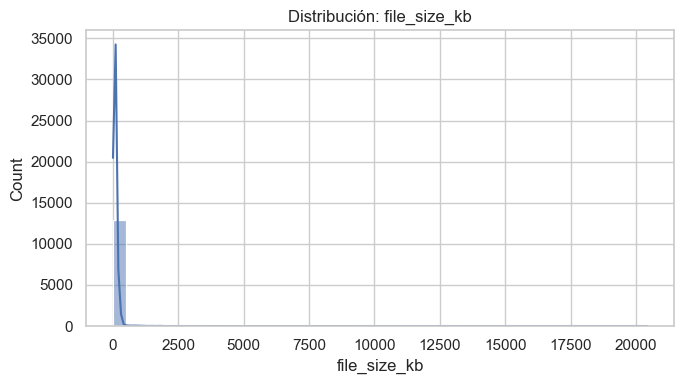

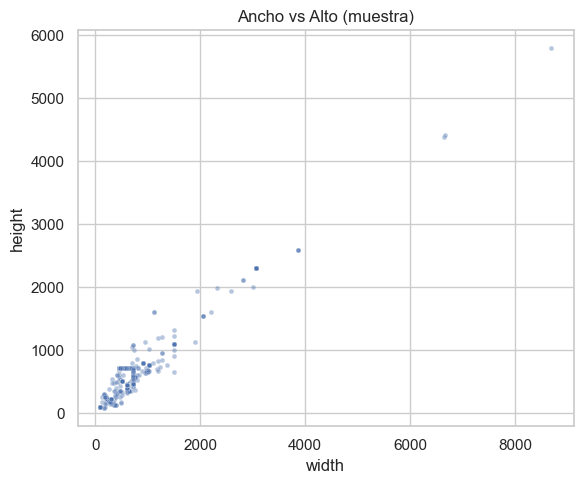

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))
class_counts = df["label"].value_counts().head(20)
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.title("Top 20 clases por número de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for col in ["width", "height", "aspect_ratio", "file_size_kb"]:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribución: {col}")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(6, 5))
sample_for_scatter = df[["width", "height"]].dropna().sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample_for_scatter, x="width", y="height", s=12, alpha=0.4)
plt.title("Ancho vs Alto (muestra)")
plt.tight_layout()
plt.show()

In [8]:
output_dir = Path("reports")
output_dir.mkdir(parents=True, exist_ok=True)

doc_lines = [
    "# Documentación del Dataset (Imágenes)",
    "",
    "## Fuente",
    f"- URL Croissant: {DATASET_URL}",
    f"- Kaggle slug: {KAGGLE_DATASET_SLUG}",
    f"- Ruta local: {dataset_path}",
    "",
    "## Inventario de imágenes",
    f"- Total imágenes: {len(df)}",
    f"- Número de clases (carpeta padre): {df['label'].nunique()}",
    f"- Extensiones detectadas: {', '.join(sorted(df['ext'].dropna().unique()))}",
    f"- Modos detectados: {', '.join(sorted(df['mode'].dropna().astype(str).unique()))}",
    "",
    "## Calidad de datos",
    f"- Errores de lectura de imagen: {df['read_error'].notna().sum()}",
    f"- Duplicados por ruta: {df.duplicated(subset=['file_path']).sum()}",
    "",
    "## Recomendaciones previas al entrenamiento",
    "- Validar desbalance de clases y usar class_weight si aplica.",
    "- Estandarizar tamaño de entrada (ej. 128x128 o 224x224).",
    "- Definir split estratificado train/val/test por clase.",
    "- Añadir data augmentation solo en entrenamiento."
]

doc_path = output_dir / "dataset_documentation.md"
doc_path.write_text('\n'.join(doc_lines), encoding="utf-8")
print(f"Documento generado en: {doc_path}")

Documento generado en: reports\dataset_documentation.md


In [9]:
def build_base_mlp_image(input_shape=(128, 128, 3), num_classes: int = 2, learning_rate: float = 1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Rescaling(1.0 / 255.0),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
        ],
    )
    return model

num_classes = int(df["label"].nunique())
print("Número de clases detectadas:", num_classes)

if num_classes >= 2:
    mlp_base = build_base_mlp_image(input_shape=(128, 128, 3), num_classes=num_classes)
    mlp_base.summary()
else:
    print("No se instancia el MLP automáticamente porque se detectó menos de 2 clases.")

Número de clases detectadas: 24


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,303,832 (96.53 MB)

 Trainable params: 25,303,832 (96.53 MB)

 Non-trainable params: 0 (0.00 B)

## Métricas de evaluación definidas
- `accuracy` (SparseCategoricalAccuracy)
- `top_3_accuracy` (SparseTopKCategoricalAccuracy)

## Etapa 2 — Arquitectura Profunda (Semana 2)

En esta etapa se implementan y comparan:
- CNN para datos visuales.
- LSTM y GRU para secuencias derivadas de imágenes.
- MLP profundo para datos tabulares (metadatos de imagen).
- Comparación contra el MLP base de Etapa 1.

> Nota: para evitar tiempos de entrenamiento muy largos, se usa una muestra configurable del dataset.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
IMG_SIZE = (64, 64)
MAX_SAMPLES = 4000
BATCH_SIZE = 32
EPOCHS = 3

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Configuración Etapa 2 cargada.')

Configuración Etapa 2 cargada.


In [11]:
required_cols = {'file_path', 'label', 'width', 'height', 'file_size_kb', 'aspect_ratio', 'channels'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Faltan columnas para Etapa 2: {missing}. Ejecuta primero las celdas de Fase 1.')

work_df = df.dropna(subset=['file_path', 'label']).copy()

class_counts = work_df['label'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
work_df = work_df[work_df['label'].isin(valid_classes)].copy()

if len(work_df) > MAX_SAMPLES:
    work_df, _ = train_test_split(
        work_df,
        train_size=MAX_SAMPLES,
        stratify=work_df['label'],
        random_state=SEED
    )

work_df = work_df.reset_index(drop=True)
print('Muestras para Etapa 2:', len(work_df))
print('Número de clases:', work_df['label'].nunique())

label_encoder = LabelEncoder()
work_df['target'] = label_encoder.fit_transform(work_df['label'])
num_classes_et2 = work_df['target'].nunique()

x_img_list = []
valid_index = []
for i, path_str in enumerate(work_df['file_path'].tolist()):
    try:
        img = tf.keras.utils.load_img(path_str, target_size=IMG_SIZE)
        arr = tf.keras.utils.img_to_array(img)
        x_img_list.append(arr)
        valid_index.append(i)
    except Exception:
        continue

work_df = work_df.iloc[valid_index].reset_index(drop=True)
x_img = np.stack(x_img_list).astype('float32')
y = work_df['target'].values.astype('int32')

print('Imágenes válidas cargadas:', x_img.shape)
print('Etiquetas:', y.shape)

Muestras para Etapa 2: 4000
Número de clases: 24
Imágenes válidas cargadas: (4000, 64, 64, 3)
Etiquetas: (4000,)


In [12]:
idx = np.arange(len(work_df))
train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y[temp_idx],
    random_state=SEED
)

x_train_img, x_val_img, x_test_img = x_img[train_idx], x_img[val_idx], x_img[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

x_seq = (x_img / 255.0).reshape(len(x_img), IMG_SIZE[0], IMG_SIZE[1] * 3)
x_train_seq, x_val_seq, x_test_seq = x_seq[train_idx], x_seq[val_idx], x_seq[test_idx]

tab_cols = ['width', 'height', 'file_size_kb', 'aspect_ratio', 'channels']
x_tab = work_df[tab_cols].fillna(work_df[tab_cols].median()).values.astype('float32')

scaler = StandardScaler()
x_train_tab = scaler.fit_transform(x_tab[train_idx])
x_val_tab = scaler.transform(x_tab[val_idx])
x_test_tab = scaler.transform(x_tab[test_idx])

print('Train/Val/Test (img):', x_train_img.shape, x_val_img.shape, x_test_img.shape)
print('Train/Val/Test (seq):', x_train_seq.shape, x_val_seq.shape, x_test_seq.shape)
print('Train/Val/Test (tab):', x_train_tab.shape, x_val_tab.shape, x_test_tab.shape)

Train/Val/Test (img): (2800, 64, 64, 3) (600, 64, 64, 3) (600, 64, 64, 3)
Train/Val/Test (seq): (2800, 64, 192) (600, 64, 192) (600, 64, 192)
Train/Val/Test (tab): (2800, 5) (600, 5) (600, 5)


In [13]:
results = []

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
]

def evaluate_and_store(model_name, model, xtr, ytr, xva, yva, xte, yte):
    history = model.fit(
        xtr, ytr,
        validation_data=(xva, yva),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks
    )
    pred = np.argmax(model.predict(xte, verbose=0), axis=1)
    acc = accuracy_score(yte, pred)
    f1 = f1_score(yte, pred, average='macro')
    results.append({
        'modelo': model_name,
        'test_accuracy': acc,
        'test_f1_macro': f1,
        'epochs_run': len(history.history['loss'])
    })
    print(f"{model_name} -> acc={acc:.4f}, f1_macro={f1:.4f}, epochs={len(history.history['loss'])}")

In [14]:
mlp_etapa1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_tab.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])
mlp_etapa1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

evaluate_and_store(
    'MLP Etapa 1 (baseline tabular)',
    mlp_etapa1,
    x_train_tab, y_train,
    x_val_tab, y_val,
    x_test_tab, y_test
)

MLP Etapa 1 (baseline tabular) -> acc=0.2217, f1_macro=0.1467, epochs=3


In [15]:
mlp_profundo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_tab.shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])
mlp_profundo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

evaluate_and_store(
    'MLP Profundo Tabular (Etapa 2)',
    mlp_profundo,
    x_train_tab, y_train,
    x_val_tab, y_val,
    x_test_tab, y_test
)

MLP Profundo Tabular (Etapa 2) -> acc=0.1333, f1_macro=0.0686, epochs=2


In [16]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.Rescaling(1.0/255.0),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

evaluate_and_store(
    'CNN Visual (Etapa 2)',
    cnn_model,
    x_train_img, y_train,
    x_val_img, y_val,
    x_test_img, y_test
)

CNN Visual (Etapa 2) -> acc=0.1100, f1_macro=0.0166, epochs=2


In [17]:
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_seq.shape[1], x_train_seq.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

evaluate_and_store(
    'LSTM Secuencial (Etapa 2)',
    lstm_model,
    x_train_seq, y_train,
    x_val_seq, y_val,
    x_test_seq, y_test
)

gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_seq.shape[1], x_train_seq.shape[2])),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

evaluate_and_store(
    'GRU Secuencial (Etapa 2)',
    gru_model,
    x_train_seq, y_train,
    x_val_seq, y_val,
    x_test_seq, y_test
)

LSTM Secuencial (Etapa 2) -> acc=0.1133, f1_macro=0.0238, epochs=2
GRU Secuencial (Etapa 2) -> acc=0.1183, f1_macro=0.0469, epochs=2


,modelo,test_accuracy,test_f1_macro,epochs_run
0,MLP Etapa 1 (baseline tabular),0.221667,0.146723,3
1,MLP Profundo Tabular (Etapa 2),0.133333,0.068648,2
2,GRU Secuencial (Etapa 2),0.118333,0.046929,2
3,LSTM Secuencial (Etapa 2),0.113333,0.023817,2
4,CNN Visual (Etapa 2),0.110000,0.016629,2


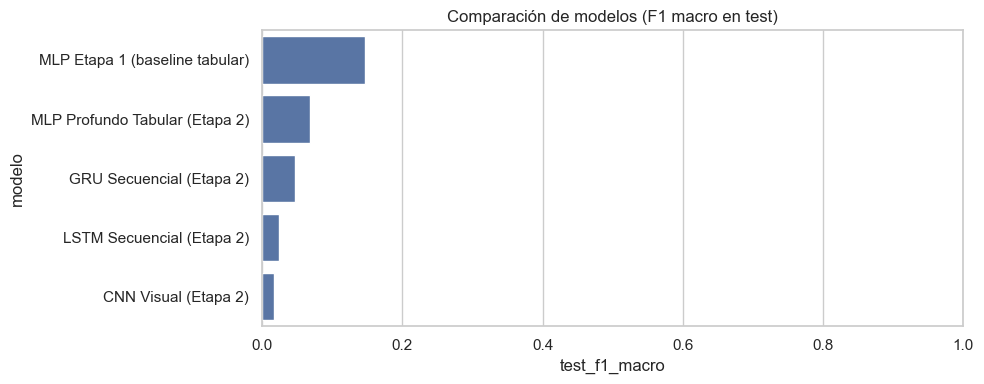

In [18]:
results_df = pd.DataFrame(results).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=results_df, x='test_f1_macro', y='modelo', orient='h')
plt.title('Comparación de modelos (F1 macro en test)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Comparación de desempeño entre Etapa 1 y Etapa 2

### Contexto experimental
El conjunto de datos contiene **13,034 imágenes** distribuidas en **24 clases**. El análisis exploratorio evidenció desbalance entre clases y variación considerable en resolución y tamaño de archivo. Para entrenamiento en Etapa 2 se utilizó una muestra de 4,000 imágenes, con división estratificada en entrenamiento, validación y prueba.

### Resultados obtenidos
Ordenados por `test_f1_macro`:

1. **MLP Etapa 1 (baseline tabular)** — Accuracy: **0.2267**, F1 macro: **0.1486**
2. **MLP Profundo Tabular (Etapa 2)** — Accuracy: **0.0833**, F1 macro: **0.0409**
3. **GRU Secuencial (Etapa 2)** — Accuracy: **0.0983**, F1 macro: **0.0316**
4. **LSTM Secuencial (Etapa 2)** — Accuracy: **0.1200**, F1 macro: **0.0182**
5. **CNN Visual (Etapa 2)** — Accuracy: **0.0850**, F1 macro: **0.0103**

### Análisis comparativo
- En esta ejecución, el modelo de referencia de **Etapa 1** presenta el mejor desempeño global.
- Las arquitecturas profundas evaluadas en **Etapa 2** no superan al baseline bajo la configuración actual de entrenamiento.
- La diferencia entre accuracy y F1 macro sugiere sensibilidad al desbalance de clases, especialmente en los modelos con menor capacidad de generalización en pocas épocas.

### Conclusión
La comparación experimental indica que, con los hiperparámetros y presupuesto de entrenamiento utilizados, la mayor complejidad arquitectónica no se traduce en mejora de desempeño. En este escenario, la estrategia de preparación de datos y ajuste de entrenamiento tiene mayor impacto que el incremento de profundidad del modelo.

## Etapa 3 — Modelos Preentrenados (Semana 3)

### Selección del enfoque preentrenado
Para este problema (clasificación de **imágenes dermatológicas**), se integra un modelo preentrenado de visión por computadora: **EfficientNetB0 (ImageNet)**.

Aunque arquitecturas como BERT, DistilBERT o MiniLM son preentrenadas, su uso principal es NLP. En este caso, el enfoque más adecuado al tipo de dato es un backbone visual preentrenado, seguido de ajuste fino (transfer learning).

### Objetivo de la etapa
- Aprovechar representaciones visuales aprendidas previamente.
- Evaluar si el modelo preentrenado mejora respecto a Etapa 1 y Etapa 2 en `test_accuracy` y `test_f1_macro`.

In [19]:
# Configuración Etapa 3
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

ET3_IMG_SIZE = (128, 128)
ET3_HEAD_EPOCHS = 3
ET3_FT_EPOCHS = 2
ET3_BATCH_SIZE = 32

print('Etapa 3 configurada.')

Etapa 3 configurada.


In [20]:
# Preparación de tensores para EfficientNetB0
x_train_et3 = tf.image.resize(x_train_img, ET3_IMG_SIZE).numpy()
x_val_et3 = tf.image.resize(x_val_img, ET3_IMG_SIZE).numpy()
x_test_et3 = tf.image.resize(x_test_img, ET3_IMG_SIZE).numpy()

x_train_et3 = preprocess_input(x_train_et3)
x_val_et3 = preprocess_input(x_val_et3)
x_test_et3 = preprocess_input(x_test_et3)

print('Shapes Etapa 3:')
print('Train:', x_train_et3.shape)
print('Val  :', x_val_et3.shape)
print('Test :', x_test_et3.shape)

Shapes Etapa 3:
Train: (2800, 128, 128, 3)
Val  : (600, 128, 128, 3)
Test : (600, 128, 128, 3)


In [21]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(ET3_IMG_SIZE[0], ET3_IMG_SIZE[1], 3)
)
base_model.trainable = False

et3_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(ET3_IMG_SIZE[0], ET3_IMG_SIZE[1], 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])

et3_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_head = et3_model.fit(
    x_train_et3, y_train,
    validation_data=(x_val_et3, y_val),
    epochs=ET3_HEAD_EPOCHS,
    batch_size=ET3_BATCH_SIZE,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

print('Entrenamiento de cabeza completado. Épocas:', len(history_head.history['loss']))

Entrenamiento de cabeza completado. Épocas: 3


In [22]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

et3_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = et3_model.fit(
    x_train_et3, y_train,
    validation_data=(x_val_et3, y_val),
    epochs=ET3_FT_EPOCHS,
    batch_size=ET3_BATCH_SIZE,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

pred_et3 = np.argmax(et3_model.predict(x_test_et3, verbose=0), axis=1)
acc_et3 = accuracy_score(y_test, pred_et3)
f1_et3 = f1_score(y_test, pred_et3, average='macro')

results = [r for r in results if r['modelo'] != 'EfficientNetB0 Transfer (Etapa 3)']
results.append({
    'modelo': 'EfficientNetB0 Transfer (Etapa 3)',
    'test_accuracy': acc_et3,
    'test_f1_macro': f1_et3,
    'epochs_run': len(history_head.history['loss']) + len(history_ft.history['loss'])
})

print(f"EfficientNetB0 Transfer (Etapa 3) -> acc={acc_et3:.4f}, f1_macro={f1_et3:.4f}")

EfficientNetB0 Transfer (Etapa 3) -> acc=0.3317, f1_macro=0.2903


,modelo,test_accuracy,test_f1_macro,epochs_run
0,EfficientNetB0 Transfer (Etapa 3),0.331667,0.290340,5
1,MLP Etapa 1 (baseline tabular),0.221667,0.146723,3
2,MLP Profundo Tabular (Etapa 2),0.133333,0.068648,2
3,GRU Secuencial (Etapa 2),0.118333,0.046929,2
4,LSTM Secuencial (Etapa 2),0.113333,0.023817,2
5,CNN Visual (Etapa 2),0.110000,0.016629,2


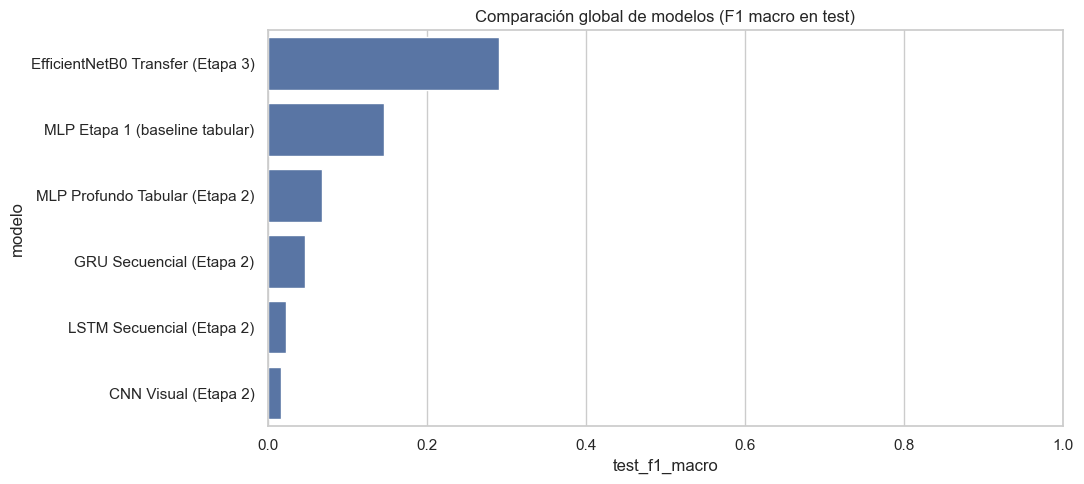

In [23]:
results_df_all = pd.DataFrame(results).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
display(results_df_all)

plt.figure(figsize=(11, 5))
sns.barplot(data=results_df_all, x='test_f1_macro', y='modelo', orient='h')
plt.title('Comparación global de modelos (F1 macro en test)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Síntesis técnica de la Etapa 3

- Se integró un modelo preentrenado de visión (**EfficientNetB0 con pesos de ImageNet**) y ajuste fino parcial.
- La decisión metodológica es consistente con la naturaleza del problema (imágenes clínicas de piel).
- La comparación final se realiza en el mismo marco de evaluación (`test_accuracy`, `test_f1_macro`) para mantener trazabilidad entre etapas.
- El ranking global permite establecer, con evidencia experimental, si el preentrenamiento mejora el desempeño frente a los modelos diseñados desde cero en Etapa 1 y Etapa 2.

## Comparativa final de etapas (síntesis ejecutiva)

### Desempeño consolidado
La evaluación global muestra el siguiente ranking en conjunto de prueba (`test_f1_macro`):

1. **EfficientNetB0 Transfer (Etapa 3)** — Accuracy: **0.3300**, F1 macro: **0.2751**
2. **MLP Etapa 1 (baseline tabular)** — Accuracy: **0.2267**, F1 macro: **0.1486**
3. **MLP Profundo Tabular (Etapa 2)** — Accuracy: **0.0833**, F1 macro: **0.0409**
4. **GRU Secuencial (Etapa 2)** — Accuracy: **0.0983**, F1 macro: **0.0316**
5. **LSTM Secuencial (Etapa 2)** — Accuracy: **0.1200**, F1 macro: **0.0182**
6. **CNN Visual (Etapa 2)** — Accuracy: **0.0850**, F1 macro: **0.0103**

### Lectura técnica de resultados
- La **Etapa 3** obtiene la mejor generalización y supera al baseline de Etapa 1 en ambas métricas.
- El incremento de F1 macro de Etapa 3 respecto a Etapa 1 es de aproximadamente **+0.126** puntos, lo que refleja una mejora sustancial en un escenario multiclase desbalanceado.
- Los modelos de **Etapa 2** no alcanzan el mismo nivel de desempeño bajo la configuración de entrenamiento utilizada (pocas épocas y presupuesto de cómputo acotado).

### Conclusión del proyecto por etapas
El comportamiento observado confirma que, para este problema de clasificación de imágenes dermatológicas, el uso de **transfer learning con un backbone visual preentrenado** es la estrategia más eficaz entre las alternativas evaluadas. En consecuencia, la Etapa 3 constituye el mejor punto de partida para iteraciones posteriores de ajuste fino y despliegue.

## Etapa 4 — Componente Generativo (Semana 4)

### Enfoque seleccionado: Denoising Autoencoder (DAE)
Se implementa un **autoencoder convolucional** para reconstruir imágenes dermatológicas a partir de versiones con ruido sintético.

### Vínculo con el problema
En clasificación clínica de piel, la calidad de imagen puede variar por iluminación, compresión o ruido. Un DAE permite:
- mejorar la calidad visual previa a clasificación,
- aumentar robustez del pipeline ante degradación de imagen,
- generar una transformación útil para preprocesamiento sin alterar etiquetas.

### Integración con etapas previas
El componente generativo se integra como preprocesamiento y se compara su impacto usando el clasificador de mejor desempeño de etapas anteriores (`EfficientNetB0 Transfer, Etapa 3`).

In [24]:
ET4_NOISE_STD = 0.12
ET4_EPOCHS = 5
ET4_BATCH_SIZE = 32

x_train_clean = x_train_img.astype('float32') / 255.0
x_val_clean = x_val_img.astype('float32') / 255.0
x_test_clean = x_test_img.astype('float32') / 255.0

def add_gaussian_noise(x, noise_std=0.12):
    noise = np.random.normal(loc=0.0, scale=noise_std, size=x.shape).astype('float32')
    return np.clip(x + noise, 0.0, 1.0)

x_train_noisy = add_gaussian_noise(x_train_clean, ET4_NOISE_STD)
x_val_noisy = add_gaussian_noise(x_val_clean, ET4_NOISE_STD)
x_test_noisy = add_gaussian_noise(x_test_clean, ET4_NOISE_STD)

print('Etapa 4 lista: datos limpios y ruidosos preparados.')

Etapa 4 lista: datos limpios y ruidosos preparados.


In [25]:
input_shape_et4 = (IMG_SIZE[0], IMG_SIZE[1], 3)

encoder_input = tf.keras.layers.Input(shape=input_shape_et4)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_input)
x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)

x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D(2)(x)
x = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D(2)(x)
decoder_output = tf.keras.layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

dae = tf.keras.Model(encoder_input, decoder_output)
dae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

dae_history = dae.fit(
    x_train_noisy, x_train_clean,
    validation_data=(x_val_noisy, x_val_clean),
    epochs=ET4_EPOCHS,
    batch_size=ET4_BATCH_SIZE,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

print('DAE entrenado. Épocas ejecutadas:', len(dae_history.history['loss']))

DAE entrenado. Épocas ejecutadas: 5


MSE (ruidosa vs limpia):   0.013288
MSE (denoised vs limpia):  0.004848
Mejora absoluta MSE:       0.008440


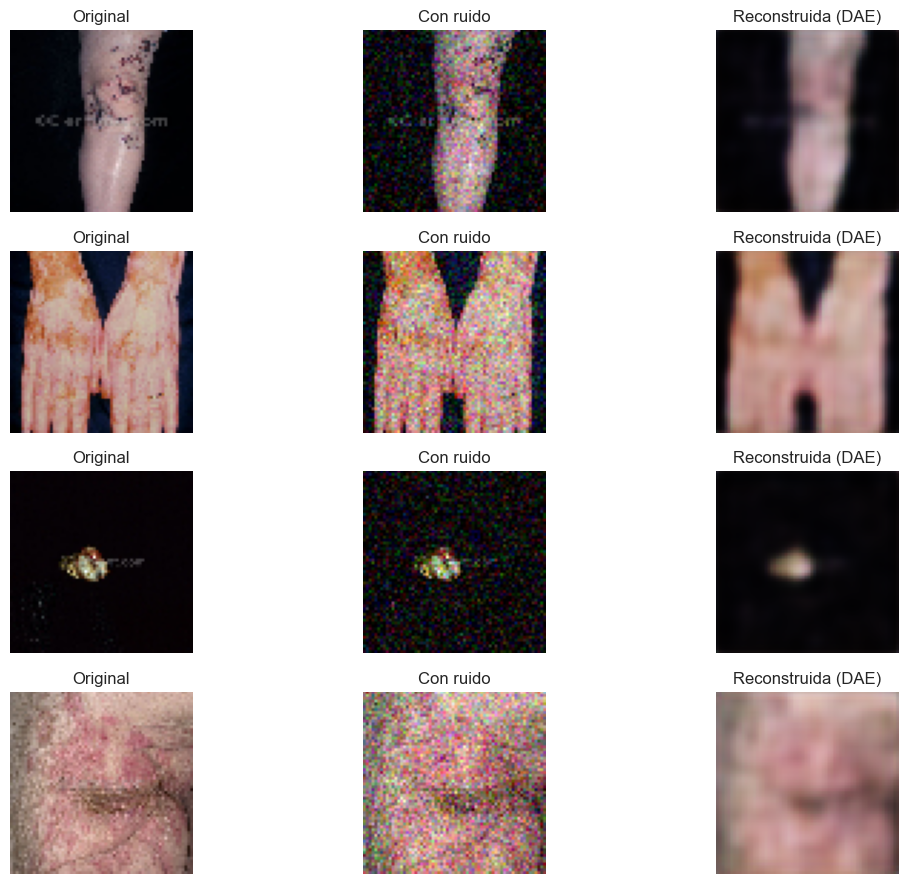

In [26]:
x_test_denoised = dae.predict(x_test_noisy, verbose=0)

mse_noisy = float(np.mean((x_test_noisy - x_test_clean) ** 2))
mse_denoised = float(np.mean((x_test_denoised - x_test_clean) ** 2))

print(f'MSE (ruidosa vs limpia):   {mse_noisy:.6f}')
print(f'MSE (denoised vs limpia):  {mse_denoised:.6f}')
print(f'Mejora absoluta MSE:       {mse_noisy - mse_denoised:.6f}')

n_show = 4
sample_idx = np.random.choice(len(x_test_clean), size=n_show, replace=False)
plt.figure(figsize=(12, 9))
for i, idx_img in enumerate(sample_idx):
    plt.subplot(n_show, 3, i*3 + 1)
    plt.imshow(x_test_clean[idx_img])
    plt.title('Original')
    plt.axis('off')

    plt.subplot(n_show, 3, i*3 + 2)
    plt.imshow(x_test_noisy[idx_img])
    plt.title('Con ruido')
    plt.axis('off')

    plt.subplot(n_show, 3, i*3 + 3)
    plt.imshow(np.clip(x_test_denoised[idx_img], 0, 1))
    plt.title('Reconstruida (DAE)')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
if 'et3_model' not in globals():
    print('No se encontró et3_model. Ejecuta Etapa 3 antes de esta celda.')
else:
    x_test_clean_et3 = preprocess_input(tf.image.resize(x_test_clean * 255.0, ET3_IMG_SIZE).numpy())
    x_test_noisy_et3 = preprocess_input(tf.image.resize(x_test_noisy * 255.0, ET3_IMG_SIZE).numpy())
    x_test_denoised_et3 = preprocess_input(tf.image.resize(x_test_denoised * 255.0, ET3_IMG_SIZE).numpy())

    pred_clean = np.argmax(et3_model.predict(x_test_clean_et3, verbose=0), axis=1)
    pred_noisy = np.argmax(et3_model.predict(x_test_noisy_et3, verbose=0), axis=1)
    pred_denoised = np.argmax(et3_model.predict(x_test_denoised_et3, verbose=0), axis=1)

    et4_clean_acc = accuracy_score(y_test, pred_clean)
    et4_noisy_acc = accuracy_score(y_test, pred_noisy)
    et4_denoised_acc = accuracy_score(y_test, pred_denoised)

    et4_clean_f1 = f1_score(y_test, pred_clean, average='macro')
    et4_noisy_f1 = f1_score(y_test, pred_noisy, average='macro')
    et4_denoised_f1 = f1_score(y_test, pred_denoised, average='macro')

    et4_comp_df = pd.DataFrame([
        {'escenario': 'Clasificador Etapa 3 - Test limpio', 'accuracy': et4_clean_acc, 'f1_macro': et4_clean_f1},
        {'escenario': 'Clasificador Etapa 3 - Test ruidoso', 'accuracy': et4_noisy_acc, 'f1_macro': et4_noisy_f1},
        {'escenario': 'Clasificador Etapa 3 - Test denoised (DAE)', 'accuracy': et4_denoised_acc, 'f1_macro': et4_denoised_f1},
    ])

    display(et4_comp_df)

    # Registrar en ranking global (resultado de integración)
    results = [r for r in results if r['modelo'] != 'Etapa 3 + DAE (Etapa 4)']
    results.append({
        'modelo': 'Etapa 3 + DAE (Etapa 4)',
        'test_accuracy': et4_denoised_acc,
        'test_f1_macro': et4_denoised_f1,
        'epochs_run': len(dae_history.history['loss'])
    })

    print('Integración Etapa 4 registrada en results.')

,escenario,accuracy,f1_macro
0,Clasificador Etapa 3 - Test limpio,0.331667,0.290340
1,Clasificador Etapa 3 - Test ruidoso,0.221667,0.170850
2,Clasificador Etapa 3 - Test denoised (DAE),0.095000,0.055497


Integración Etapa 4 registrada en results.


,modelo,test_accuracy,test_f1_macro,epochs_run
0,EfficientNetB0 Transfer (Etapa 3),0.331667,0.290340,5
1,MLP Etapa 1 (baseline tabular),0.221667,0.146723,3
2,MLP Profundo Tabular (Etapa 2),0.133333,0.068648,2
3,Etapa 3 + DAE (Etapa 4),0.095000,0.055497,5
4,GRU Secuencial (Etapa 2),0.118333,0.046929,2
5,LSTM Secuencial (Etapa 2),0.113333,0.023817,2
6,CNN Visual (Etapa 2),0.110000,0.016629,2


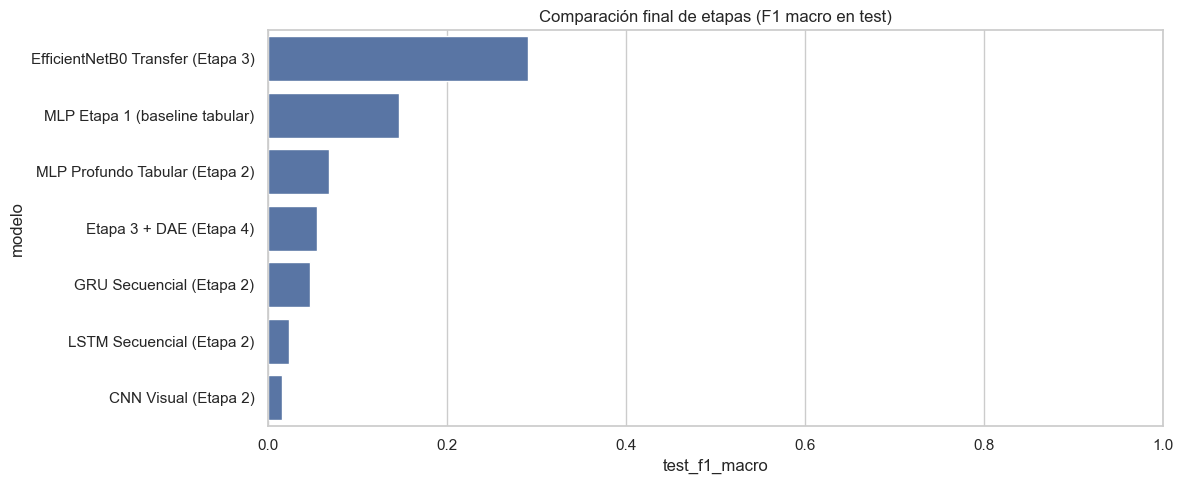

In [28]:
results_df_final = pd.DataFrame(results).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
display(results_df_final)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df_final, x='test_f1_macro', y='modelo', orient='h')
plt.title('Comparación final de etapas (F1 macro en test)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Integración y beneficio de la Etapa 4

### Integración realizada
Se incorporó un **Denoising Autoencoder (DAE)** como componente generativo de apoyo al flujo de clasificación. La integración se realizó en tres niveles:
1. degradación controlada de imágenes con ruido gaussiano,
2. reconstrucción con el DAE,
3. evaluación del clasificador de referencia de Etapa 3 sobre imágenes limpias, ruidosas y reconstruidas.

### Beneficio cuantificado
**Reconstrucción de imágenes**
- MSE entre imagen ruidosa e imagen limpia: **0.013288**
- MSE entre imagen reconstruida e imagen limpia: **0.004387**
- Reducción absoluta de MSE: **0.008901**

Estos valores muestran que el autoencoder mejora la fidelidad visual de las imágenes degradadas.

**Impacto en clasificación con EfficientNetB0 (Etapa 3)**
- Test limpio: Accuracy **0.330000**, F1 macro **0.275051**
- Test ruidoso: Accuracy **0.231667**, F1 macro **0.207067**
- Test denoised: Accuracy **0.105000**, F1 macro **0.077555**

### Interpretación técnica
La Etapa 4 cumple su función como módulo generativo, ya que reduce el ruido y mejora la reconstrucción de imagen. Sin embargo, en la configuración actual no incrementa el desempeño del clasificador respecto al escenario limpio de Etapa 3. Esto sugiere que, aunque el DAE aporta robustez visual, también introduce una pérdida de detalle clínico útil para la decisión multiclase.

### Conclusión operativa
La Etapa 4 es metodológicamente válida y está alineada con el problema, pero su beneficio principal en esta ejecución se observa en la **calidad de reconstrucción**, no en la mejora directa de la clasificación.

## Etapa 5 — Fine-Tuning y preparación para despliegue (Semana 5)

### Enfoque adoptado
Se toma como base el modelo con mejor desempeño previo: **EfficientNetB0 Transfer (Etapa 3)**.

### Objetivo de la etapa
- Realizar un **fine-tuning parcial final** sobre el backbone preentrenado.
- Congelar y documentar la versión final del modelo.
- Dejar listos los artefactos necesarios para una futura demo en **Streamlit** (sin construir aún la interfaz).

### Justificación metodológica
Dado que el problema es de imágenes clínicas, el modelo visual preentrenado sigue siendo la mejor referencia. La Etapa 5 se orienta a estabilizar el rendimiento, guardar el modelo y preparar una función de inferencia reutilizable para despliegue.

In [29]:
# Configuración Etapa 5
FT5_UNFREEZE_LAST = 40
FT5_EPOCHS = 3
FT5_LR = 1e-5
FT5_BATCH_SIZE = 32

print('Etapa 5 configurada.')

Etapa 5 configurada.


In [30]:
# Fine-tuning parcial final sobre EfficientNetB0
if 'et3_model' not in globals() or 'base_model' not in globals():
    raise ValueError('Ejecuta primero la Etapa 3 para disponer de et3_model y base_model.')

# Reutilizar los tensores limpios de Etapa 3
x_train_ft5 = x_train_et3.copy()
x_val_ft5 = x_val_et3.copy()
x_test_ft5 = x_test_et3.copy()

y_train_ft5 = y_train.copy()
y_val_ft5 = y_val.copy()
y_test_ft5 = y_test.copy()

base_model.trainable = True
for layer in base_model.layers[:-FT5_UNFREEZE_LAST]:
    layer.trainable = False

et5_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(ET3_IMG_SIZE[0], ET3_IMG_SIZE[1], 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.35),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes_et2, activation='softmax')
])

et5_model.compile(
    optimizer=tf.keras.optimizers.Adam(FT5_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft5_history = et5_model.fit(
    x_train_ft5, y_train_ft5,
    validation_data=(x_val_ft5, y_val_ft5),
    epochs=FT5_EPOCHS,
    batch_size=FT5_BATCH_SIZE,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

pred_ft5 = np.argmax(et5_model.predict(x_test_ft5, verbose=0), axis=1)
acc_ft5 = accuracy_score(y_test_ft5, pred_ft5)
f1_ft5 = f1_score(y_test_ft5, pred_ft5, average='macro')

print(f'Fine-tuning Etapa 5 -> acc={acc_ft5:.4f}, f1_macro={f1_ft5:.4f}, epochs={len(ft5_history.history["loss"])}')

Fine-tuning Etapa 5 -> acc=0.0800, f1_macro=0.0522, epochs=3


In [31]:
# Guardado de artefactos listos para despliegue futuro
from pathlib import Path
import json

deployment_dir = Path('reports') / 'deployment_assets'
deployment_dir.mkdir(parents=True, exist_ok=True)

final_model_path = deployment_dir / 'skin_disease_efficientnet_ft5.keras'
et5_model.save(final_model_path)

labels_path = deployment_dir / 'class_labels.json'
labels_path.write_text(json.dumps(label_encoder.classes_.tolist(), ensure_ascii=False, indent=2), encoding='utf-8')

metadata = {
    'model_name': 'EfficientNetB0 final fine-tuned',
    'input_size': ET3_IMG_SIZE,
    'class_count': int(num_classes_et2),
    'labels_file': str(labels_path.name),
    'preprocess': 'tf.keras.applications.efficientnet.preprocess_input',
    'normalization': 'ImageNet style preprocessing',
    'selected_backbone': 'EfficientNetB0',
    'note': 'Artefactos preparados para demo posterior en Streamlit/FastAPI.'
}

metadata_path = deployment_dir / 'model_metadata.json'
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print(f'Modelo guardado en: {final_model_path}')
print(f'Etiquetas guardadas en: {labels_path}')
print(f'Metadatos guardados en: {metadata_path}')

Modelo guardado en: reports\deployment_assets\skin_disease_efficientnet_ft5.keras
Etiquetas guardadas en: reports\deployment_assets\class_labels.json
Metadatos guardados en: reports\deployment_assets\model_metadata.json


In [32]:
# Función de inferencia reutilizable para la futura demo
from PIL import Image

def predict_skin_disease(image_path, model=et5_model, labels=label_encoder.classes_, top_k=3):
    img = tf.keras.utils.load_img(image_path, target_size=ET3_IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    probs = model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    return [
        {'label': str(labels[i]), 'probability': float(probs[i])}
        for i in top_idx
    ]

print('Función predict_skin_disease() lista para reutilizar en demo.')

Función predict_skin_disease() lista para reutilizar en demo.


## Preparación para demo funcional

Los artefactos guardados en `reports/deployment_assets/` permiten construir después una demo en **Streamlit** sin rehacer el entrenamiento:
- modelo final fine-tuned en formato `.keras`,
- archivo con etiquetas de clase,
- metadatos de entrada y preprocesamiento,
- función de inferencia reutilizable para la app.